1. Clean raw data

In [1]:
import numpy as np
import pandas as pd
from Data.data_cleaning import Datacleaner

In [ ]:
cleaner = Datacleaner("./Data/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2607,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

cleaner.save_data("Data/Dataset_clean.csv")

In [2]:
df = pd.read_csv("./Data/Dataset_clean.csv")

# Remove season 2025-2026 because incomplete
df = df[df['Season'] != '2025-2026']
df.to_csv("./Data/Dataset_clean_25.csv", index=False)


In [3]:
# Split the dataframe into train and test sets (last x rows for test)
n_total = len(df)

n_test = 153

train_df = df.iloc[:-n_test].copy()
test_df = df.iloc[-n_test:].copy()


# get data for train
teams = sorted(pd.unique(train_df[['HomeTeam','AwayTeam']].values.ravel()))

team_index ={team:i for i,team in enumerate(teams)}

n= len(teams)

# Victory Matrix
W = np.zeros((n,n), dtype=int)

# Draw Matrix
D = np.zeros((n,n), dtype=int)

for _,row in train_df.iterrows():

    i = team_index[row['HomeTeam']]
    j = team_index[row['AwayTeam']]

    if row['FTR'] == 'H':
        W[i,j] += 1
    elif row['FTR'] == 'A':
        W[j,i] += 1
    elif row['FTR'] == 'D':
        D[i,j] += 1
        D[j,i] += 1

train_data = {'Teams': teams,
                'Victory Matrix': W,
                'Draw Matrix': D}

W_matrix = train_data['Victory Matrix']
D_matrix = train_data['Draw Matrix']


Tolerance threshold attained after 234 iterations
Model fitted successfully !
Tolerance threshold attained after 236 iterations
Model fitted successfully !
Tolerance threshold attained after 237 iterations
Model fitted successfully !
Tolerance threshold attained after 239 iterations
Model fitted successfully !
Tolerance threshold attained after 241 iterations
Model fitted successfully !
Tolerance threshold attained after 244 iterations
Model fitted successfully !
Tolerance threshold attained after 247 iterations
Model fitted successfully !
Tolerance threshold attained after 250 iterations
Model fitted successfully !
Tolerance threshold attained after 255 iterations
Model fitted successfully !
Tolerance threshold attained after 260 iterations
Model fitted successfully !
Tolerance threshold attained after 266 iterations
Model fitted successfully !
Tolerance threshold attained after 273 iterations
Model fitted successfully !
Tolerance threshold attained after 281 iterations
Model fitted s

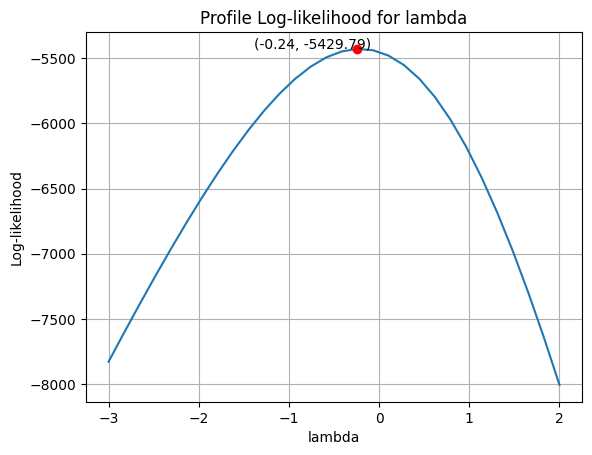

In [24]:
# Calibrate lambda

from BradleyTerry_classical.functions import BT_calibrate
from BradleyTerry_classical.BT_classical import BradleyTerry

Lambda_Chooser = BT_calibrate(W= W_matrix, D= D_matrix, teams= teams)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)


In [4]:
# Train the model
from BradleyTerry_classical.BT_classical import BradleyTerry

bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(W=W_matrix, D=D_matrix, teams=teams)

strength = bt_model.predict_strength()

Tolerance threshold attained after 333 iterations
Model fitted successfully !


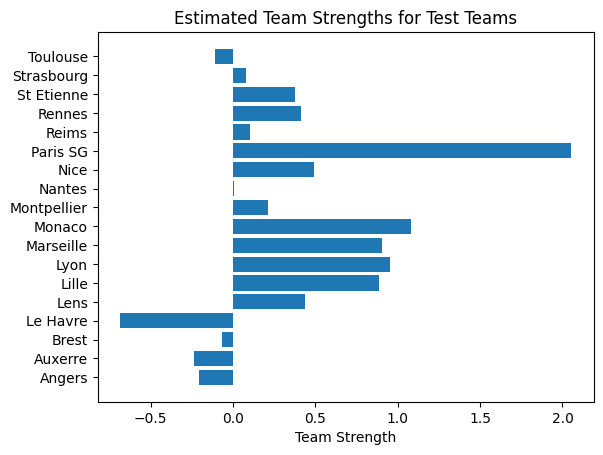

In [6]:
team_test =sorted(pd.unique(test_df[['HomeTeam','AwayTeam']].values.ravel()))

# plot strenght of test teams with horizontal bars
import matplotlib.pyplot as plt
strength_test = [strength[team] for team in team_test]
plt.barh(team_test, strength_test)
plt.xlabel("Team Strength")
plt.title("Estimated Team Strengths for Test Teams")
plt.show()

In [31]:
from Test.test_BT_classical import BT_Test

Test = BT_Test(model=bt_model, test_df=test_df)

Test.logLoss()

Test.baseline_logloss()

LogLoss on test data: 1.0210
LogLoss on test data (baseline): 1.0986


np.float64(1.0986122886681071)